In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("two_moons.csv")
df.head()

,x1,x2,label
0,0.830858,-0.334342,1
1,0.991710,0.879000,0
2,1.107245,-0.470344,1
3,-0.140899,1.033148,0
4,0.405592,1.328529,0


In [3]:
df.describe()

,x1,x2,label
count,500.000000,500.000000,500.000000
mean,0.518145,0.255367,0.500000
std,0.895432,0.543603,0.500501
min,-1.476127,-0.988526,0.000000
25%,-0.086818,-0.195163,0.000000
50%,0.479565,0.280467,0.500000
75%,1.122974,0.685076,1.000000
max,2.484802,1.504279,1.000000


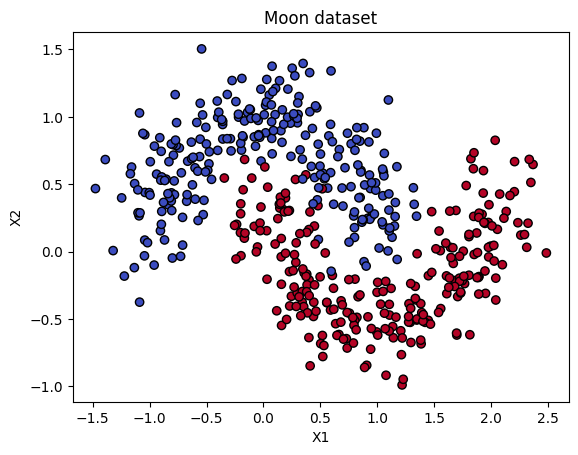

In [4]:
plt.scatter(
    x=df["x1"],
    y=df["x2"],
    c=df["label"],
    cmap="coolwarm",
    edgecolors="black"
    )
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Moon dataset")
plt.show()

In [5]:
X = df.drop("label",axis=1)
Y = df["label"]


In [6]:
X.shape

(500, 2)

In [7]:
X.head()

,x1,x2
0,0.830858,-0.334342
1,0.991710,0.879000
2,1.107245,-0.470344
3,-0.140899,1.033148
4,0.405592,1.328529


In [8]:
Y.shape

(500,)

In [9]:
Y.head()

0    1
1    0
2    1
3    0
4    0
Name: label, dtype: int64

In [10]:
X = X.to_numpy()
Y = Y.to_numpy()


In [11]:
def layer_size(X,Y):
    n_x = X.shape[1]
    n_h = 4
    n_y = 1
    return n_x,n_h,n_y

In [12]:
n_x,n_h,n_y = layer_size(X,Y)

In [13]:
def initialize_parameters(n_x,n_h,n_y):
    np.random.seed(42)
    w1 = np.random.randn(n_h,n_x)*0.01
    b1 = np.zeros((n_h,1))
    w2 = np.random.randn(n_y,n_h)*0.01
    b2 = np.zeros((n_y,1))
    
    paramters = {
        "w1" : w1,
        "b1" : b1,
        "w2" : w2,
        "b2" : b2
    }
    return paramters

In [14]:
parameters = initialize_parameters(n_x,n_h,n_y)
print("w1 : ",parameters["w1"])
print("b1 : ",parameters["b1"])
print("w2 : ",parameters["w2"])
print("b2 : ",parameters["b2"])


w1 :  [[ 0.00496714 -0.00138264]
 [ 0.00647689  0.0152303 ]
 [-0.00234153 -0.00234137]
 [ 0.01579213  0.00767435]]
b1 :  [[0.]
 [0.]
 [0.]
 [0.]]
w2 :  [[-0.00469474  0.0054256  -0.00463418 -0.0046573 ]]
b2 :  [[0.]]


In [15]:
def sigmoid(A):
    return 1/(1+np.exp(-(A)))

In [26]:
def forward_propagation(X,parametes):
    W1 = parametes["w1"]
    b1 = parametes["b1"]
    W2 = parametes["w2"]
    b2 = parametes["b2"]
    
    Z1 = np.dot(X,W1.T)+b1.T
    A1 = np.tanh(Z1)
    Z2 = np.dot(A1,W2.T) + b2.T
    A2 = sigmoid(Z2)
    cache = {
        "Z1" : Z1,
        "Z2" : Z2,
        "A1" : A1,
        "A2" : A2
    }
    return cache,A2

In [27]:
cache,A2 = forward_propagation(X,parameters)
print("A2 : ",A2)

A2 :  [[0.49998406]
 [0.5000015 ]
 [0.49997837]
 [0.50001838]
 [0.50001617]
 [0.49997519]
 [0.49998137]
 [0.50001811]
 [0.50000274]
 [0.49997296]
 [0.49998752]
 [0.50001277]
 [0.49996848]
 [0.50000829]
 [0.49997474]
 [0.49997539]
 [0.49998041]
 [0.49999558]
 [0.4999817 ]
 [0.49997305]
 [0.49998004]
 [0.49997914]
 [0.50000626]
 [0.49998247]
 [0.50000312]
 [0.49998791]
 [0.49998342]
 [0.50001729]
 [0.50001865]
 [0.49998965]
 [0.49997529]
 [0.49999158]
 [0.49997177]
 [0.50002049]
 [0.49999215]
 [0.49998469]
 [0.49997966]
 [0.5000024 ]
 [0.50002118]
 [0.50000473]
 [0.49997141]
 [0.50001471]
 [0.49998524]
 [0.50001621]
 [0.49999153]
 [0.50000356]
 [0.49998736]
 [0.49999113]
 [0.4999719 ]
 [0.49999418]
 [0.50001503]
 [0.5000272 ]
 [0.50001839]
 [0.49997723]
 [0.50001951]
 [0.50000767]
 [0.50001881]
 [0.4999927 ]
 [0.50002029]
 [0.50001451]
 [0.49998073]
 [0.50000636]
 [0.49999132]
 [0.49997614]
 [0.50001261]
 [0.49999877]
 [0.49997422]
 [0.50000191]
 [0.50000982]
 [0.49997606]
 [0.49997779]


In [28]:
def find_cost(A2,Y):
    m = Y.shape[0]
    inner_val = np.multiply(np.log(A2),Y)+ np.multiply(np.log(1-A2),(1-Y))
    cost = -(1/m) * np.sum(inner_val)
    cost = float(np.squeeze(cost))
    return cost


In [29]:
cost = find_cost(A2,Y)
print(cost)

346.5735905710941


In [33]:
def back_propagation(parameters,cache,X,Y):
    m = X.shape[0]
    W1 = parameters["w1"]
    W2 = parameters["w2"]
    A1 = cache["A1"]
    A2 = cache["A2"]
    
    dZ2 = A2 - Y
    dW2 = (1/m) * np.dot(dZ2.T, A1)
    db2 = (1/m) * np.sum(dZ2,axis = 0, keepdims = True)
    
    dZ1 = np.dot(dZ2,W2) * (1 - np.power(A1, 2))
    dW1 = (1/m) * np.dot(dZ1.T,X)
    db1 = (1/m)*np.sum(dZ1,axis=0,keepdims=True).T
    
    grads = {
        "dW1" : dW1,
        "dW2" : dW2,
        "db1" : db1,
        "db2" : db2
    }
    return grads
    